<font size=5><center><u> **Game of Life** </center>


In [1]:
# import packages
import numpy as np
import random
import time

import matplotlib as mpl
import matplotlib.pyplot as plt

from IPython.display import clear_output


In [2]:
def ecosystem(size, num_ones):
    # create an array of zeros
    cell_count = size[0] * size[1]
    arr = [0] * cell_count
    
    # randomly place the specified number of ones
    ones_idx = random.sample(range(cell_count), num_ones)
    for idx in ones_idx:
        arr[idx] = 1
    
    arr = np.array(arr).reshape(size[0], size[1])
    
    return arr

In [3]:
def evolve(system):
    
    radius = 1
    
    new_system = []
    
    for i in range(len(system)):
        temp = []
        for j in range(len(system[i])):
            center = (i,j)
            if center[0]==0 and center[1]==0:
                sub = system[center[0]:center[0] + radius + 1,
                             center[1]:center[1]+ radius + 1]
            elif center[0]==0 and center[1]!=0:
                sub = system[center[0]:center[0] + radius + 1,
                             center[1] - radius:center[1] + radius + 1]
            elif center[0]!=0 and center[1]==0:
                sub = system[center[0] - radius:center[0] + radius + 1,
                             center[1]:center[1]+ radius + 1]
            else:
                sub = system[center[0] - radius:center[0] + radius + 1,
                             center[1] - radius:center[1] + radius + 1]
            
            if system[i][j]==1 and (np.sum(sub)-system[i][j])<2:
                temp.append(0)
            elif system[i][j]==1 and (np.sum(sub)-system[i][j])>3:
                temp.append(0)
            elif system[i][j]==1 and (np.sum(sub)-system[i][j])==2 or (np.sum(sub)-system[i][j])==3:
                temp.append(1)
            elif system[i][j]==0 and (np.sum(sub)-system[i][j])==3:
                temp.append(1)
            else:
                temp.append(0)
        
        new_system.append(temp)
    
    new_system = np.array(new_system)
    
    return new_system

In [4]:
def GoL(size, num_ones, evolutions):

    system = ecosystem(size, num_ones)

    prev_system = [system, system, system]

    years = 0

    colours = ['lightgreen', 
               'pink', 
               'lightblue', 
               'lightsalmon', 
               'thistle']
    colour = random.choice(colours)
    
    for i in range(evolutions):
      
        print()
        print()
        print()
        print()
        print()
        print()
        print()
        print()
       
        clear_output(wait=True)
        
        # make a color map of fixed colors
        cmap = mpl.colors.ListedColormap(['white', colour])
        bounds=[0,1]
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

        # make plot
        fig, ax = plt.subplots(figsize=(5, 5))
        
        # tell imshow about color map so that only set colors are used
        img = ax.imshow(system,interpolation='nearest',
                        cmap = cmap,norm=norm)

        # make a color bar
        plt.colorbar(img,ax=ax, cmap=cmap,
                        norm=norm,boundaries=bounds,ticks=[-1,0])

        # visualisation time step
        time.sleep(0.05)
        
        # hide axis ticks
        plt.xticks([])
        plt.yticks([])

        # hide colorbar
        fig.delaxes(fig.axes[1])
        
        # layout
        plt.tight_layout()
        
        plt.show()
        
        system = evolve(system)

        prev_system.append(system)
        
        if np.sum(system)==0:
            print('-------Life ceases to exist-------')
            print(f'Population Survived: {years} years')
            break
        elif (prev_system[0]==system).all() or (prev_system[1]==system).all():
            print('---------Life finds a way---------')
            print(f'Population Survived: {years} years')
            print('-------Population will live-------')
            break
        else:
            del prev_system[0]
        
        years+=1
        
    if years==evolutions:
        print('---------Life finds a way---------')
        print(f'Population Survived: {years} years')
        
    return

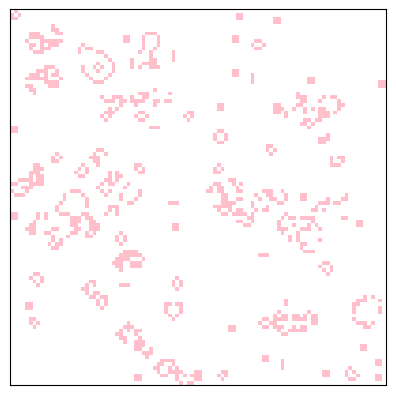

---------Life finds a way---------
Population Survived: 100 years


In [5]:
size = (100,100)
num_ones = 5000
evolutions = 100
GoL(size, num_ones, evolutions)